#request resources + use analy environment


salloc --partition test --time 0-04:00 --mem 20gb
module load python
mamba activate analy
cd /n/home07/than157/desktop/done-large_projects/learn-better/evolm/finetune/llama-factory/
jupyter notebook --no-browser --ip=0.0.0.0 --port=8888

In [1]:
from datasets import load_dataset
import pandas as pd
import json
from tqdm import tqdm

### load data

In [2]:
#load training set
dataset = load_dataset(path="qiaojin/PubMedQA", name="pqa_artificial", split="train")

#print dataset info
print("Dataset info:")
print(dataset)

#convert to dataframe
df = dataset.to_pandas()

print("# samples:", df.shape[0])

df.head()


Dataset info:
Dataset({
    features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
    num_rows: 211269
})
# samples: 211269


,pubid,question,context,long_answer,final_decision
0,25429730,Are group 2 innate lymphoid cells ( ILC2s ) in...,{'contexts': ['Chronic rhinosinusitis (CRS) is...,"As ILC2s are elevated in patients with CRSwNP,...",yes
1,25433161,Does vagus nerve contribute to the development...,{'contexts': ['Phosphatidylethanolamine N-meth...,Neuronal signals via the hepatic vagus nerve c...,yes
2,25445714,Does psammaplin A induce Sirtuin 1-dependent a...,{'contexts': ['Psammaplin A (PsA) is a natural...,PsA significantly inhibited MCF-7/adr cells pr...,yes
3,25431941,Is methylation of the FGFR2 gene associated wi...,{'contexts': ['This study examined links betwe...,We identified a novel biologically plausible c...,yes
4,25432519,Do tumor-infiltrating immune cell profiles and...,{'contexts': ['Tumor microenvironment immunity...,Breast cancer immune cell subpopulation profil...,yes


### format input and output for SFT

In [3]:
def write_sft_input(row):
    #extract variables
    abstract_sentences = row['context']['contexts'].tolist()
    abstract_paragraph = " ".join(abstract_sentences)
    question = row['question']
    
    #write sft input
    sft_input = f'''Based on the paper abstract below, answer the following question with 'yes', 'maybe', or 'no'.

Question: {question}

Abstract: {abstract_paragraph}'''

    return sft_input

In [4]:
def write_sft_output(row):
    #extract variables
    long_answer = row['long_answer']
    final_decision = row['final_decision']

    #write sft output
    sft_output = f"The conclusion of the abstract is: {long_answer} Therefore, the answer is {final_decision}."

    return sft_output

In [5]:
#format input and output for all rows
df['sft_input'] = df.apply(write_sft_input, axis=1)
df['sft_output'] = df.apply(write_sft_output, axis=1)

In [6]:
#look at example
idx = 1
print('sft_input:')
print(df.iloc[idx]['sft_input'])

print('\nsft_output:')
print(df.iloc[idx]['sft_output'])

sft_input:
Based on the paper abstract below, answer the following question with 'yes', 'maybe', or 'no'.

Question: Does vagus nerve contribute to the development of steatohepatitis and obesity in phosphatidylethanolamine N-methyltransferase deficient mice?

Abstract: Phosphatidylethanolamine N-methyltransferase (PEMT), a liver enriched enzyme, is responsible for approximately one third of hepatic phosphatidylcholine biosynthesis. When fed a high-fat diet (HFD), Pemt(-/-) mice are protected from HF-induced obesity; however, they develop steatohepatitis. The vagus nerve relays signals between liver and brain that regulate peripheral adiposity and pancreas function. Here we explore a possible role of the hepatic branch of the vagus nerve in the development of diet induced obesity and steatohepatitis in Pemt(-/-) mice. 8-week old Pemt(-/-) and Pemt(+/+) mice were subjected to hepatic vagotomy (HV) or capsaicin treatment, which selectively disrupts afferent nerves, and were compared to sh

### check that input and output lengths are reasonable

In [7]:
#calculate lengths
df['sft_input_length'] = df["sft_input"].str.len()
df['sft_output_length'] = df["sft_output"].str.len()
df['total_length'] = df['sft_input_length'] + df['sft_output_length']

In [8]:
#summary stats
print(df['sft_input_length'].describe())
print(df['sft_output_length'].describe())
print(df['total_length'].describe())

count    211269.000000
mean       1602.874004
std         339.897171
min         187.000000
25%        1395.000000
50%        1600.000000
75%        1789.000000
max        5855.000000
Name: sft_input_length, dtype: float64
count    211269.000000
mean        325.353161
std         127.024713
min          66.000000
25%         237.000000
50%         303.000000
75%         386.000000
max        3405.000000
Name: sft_output_length, dtype: float64
count    211269.000000
mean       1928.227165
std         372.014164
min         350.000000
25%        1702.000000
50%        1928.000000
75%        2118.000000
max        7196.000000
Name: total_length, dtype: float64


<Axes: ylabel='Frequency'>

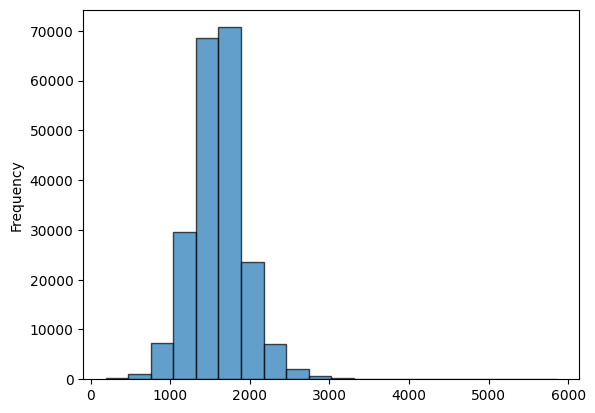

In [9]:
df['sft_input_length'].plot(kind='hist', bins=20, edgecolor='black', alpha=0.7)

<Axes: ylabel='Frequency'>

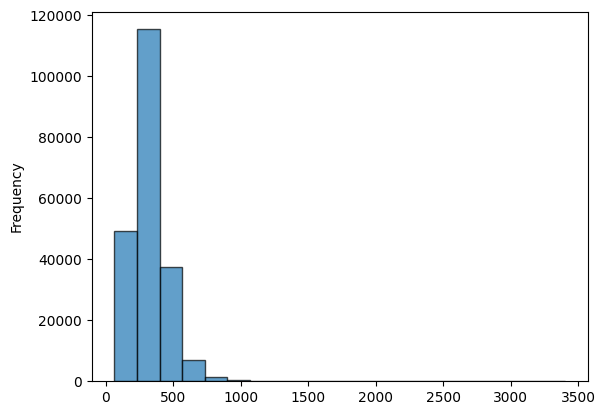

In [10]:
df['sft_output_length'].plot(kind='hist', bins=20, edgecolor='black', alpha=0.7)


In [11]:
### remove rows with very long inputs or outputs
print('# rows with very long inputs (4000+ characters):', df[df['sft_input_length'] > 4000].shape[0])
print('# rows with very long outputs (1500+ characters):', df[df['sft_output_length'] > 1500].shape[0])

df = df[df['sft_input_length'] < 4000]
df = df[df['sft_output_length'] < 1500]
df.shape

#re-examine summary stats
print(df['sft_input_length'].describe())
print(df['sft_output_length'].describe())
print(df['total_length'].describe())

# rows with very long inputs (4000+ characters): 44
# rows with very long outputs (1500+ characters): 58
count    211168.000000
mean       1602.334061
std         336.513469
min         187.000000
25%        1396.000000
50%        1600.000000
75%        1789.000000
max        3985.000000
Name: sft_input_length, dtype: float64
count    211168.000000
mean        324.888695
std         124.210779
min          66.000000
25%         237.000000
50%         303.000000
75%         386.000000
max        1497.000000
Name: sft_output_length, dtype: float64
count    211168.000000
mean       1927.222756
std         367.778184
min         350.000000
25%        1702.000000
50%        1928.000000
75%        2118.000000
max        4851.000000
Name: total_length, dtype: float64


In [12]:
### remove rows that exceed max_output_length

#autoregressive models:
#output length cannot exceed context_window_size-input_length (2048*3 characters - sft_input_length)
max_output_length = 2048*3 - df['sft_input_length']
df['max_output_length'] = max_output_length

#keep only rows where output length is less than max_output_length
df = df[df['sft_output_length'] < max_output_length]
df.shape

(211168, 11)

In [13]:
#re-examine summary stats
print(df['sft_input_length'].describe())
print(df['sft_output_length'].describe())
print(df['total_length'].describe())

count    211168.000000
mean       1602.334061
std         336.513469
min         187.000000
25%        1396.000000
50%        1600.000000
75%        1789.000000
max        3985.000000
Name: sft_input_length, dtype: float64
count    211168.000000
mean        324.888695
std         124.210779
min          66.000000
25%         237.000000
50%         303.000000
75%         386.000000
max        1497.000000
Name: sft_output_length, dtype: float64
count    211168.000000
mean       1927.222756
std         367.778184
min         350.000000
25%        1702.000000
50%        1928.000000
75%        2118.000000
max        4851.000000
Name: total_length, dtype: float64


### create json file for SFT on training set

In [14]:
### create json file

#format data for sft
data = []

for idx in tqdm(range(df.shape[0])):
    row = df.iloc[idx]
    item = {
        "instruction": row["sft_input"],
        "input": "",
        "output": row["sft_output"]
    }
    data.append(item)

#save to JSON file
with open("data/pubmedqa.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=4)

print("Final # of samples in json file:", len(data))
print("Complete!")

100%|███████████████████████████████████████| 211168/211168 [00:06<00:00, 30184.14it/s]


Final # of samples in json file: 211168
Complete!


In [16]:
#look at example
idx = 3
print('sft_input:')
print(df.iloc[idx]['sft_input'])

print('\nsft_output:')
print(df.iloc[idx]['sft_output'])

sft_input:
Based on the paper abstract below, answer the following question with 'yes', 'maybe', or 'no'.

Question: Is methylation of the FGFR2 gene associated with high birth weight centile in humans?

Abstract: This study examined links between DNA methylation and birth weight centile (BWC), and explored the impact of genetic variation. Using HumanMethylation450 arrays, we examined candidate gene-associated CpGs in cord blood from newborns with low (<15th centile), medium (40-60th centile) and high (>85th centile) BWC (n = 12). Candidates were examined in an investigation cohort (n = 110) using pyrosequencing and genotyping for putative methylation-associated polymorphisms performed using standard PCR. Array analysis identified 314 candidate genes associated with BWC extremes, four of which showed ≥ 4 BWC-linked CpGs. Of these, PM20D1 and MI886 suggested genetically determined methylation levels. However, methylation at three CpGs in FGFR2 remained significantly associated with high

In [ ]:
#load data
#format data for sft

#look for very long inputs or responses lengths

